In [33]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib import rcParams
import pandas as pd
import seaborn as sns
matplotlib_font_size=7
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Helvetica']
rcParams['font.size'] = matplotlib_font_size


path_figures=Path().cwd().parent.parent/"figures"
path_figures.mkdir(parents=True, exist_ok=True)
path_benchmark_data=Path.cwd().parent.parent/"benchmark_for_cache_list_threshold"
path_benchmark_data.mkdir(parents=True, exist_ok=True)

In [34]:
steps=[
    "open_search", 
    "neutral_loss_search",
    "hybrid_search"
    ]

cache_list_threshold=[
    1_000,
    5_000, 
    10_000,50_000,
    100_000, 500_000, 1_000_000,5_000_000
    ]

library_size=1_000_000
query_size=100
ion_mode=[
    -1, 
    1
    ]


In [35]:

df=[]
for charge in ion_mode:
    for threshold in cache_list_threshold:
        for i in range(query_size):
            data={"total_library_number":library_size, "query_idx":i, "charge":charge, "cache_list_threshold": threshold}
            
            for step in steps:       
                
                # path_benchmark_dynamic_fast_search=path_benchmark_data/f"dynamic_fast_search_{charge}_{library_size}_compare_time_{step}_step_query_{i}.txt"
                path_benchmark_specific_data_dynamic=path_benchmark_data/f"dynamic_fast_update_{charge}_{library_size}_cache_{threshold}_memory_usage_{step}_step_query_{i}.txt"
                
                with open(path_benchmark_specific_data_dynamic,"r") as f1:
                    for line in f1.readlines():
                        items=line.split(":", maxsplit=1)
                        key, value=items
                        if key.strip()=="Maximum resident set size (kbytes)":
                            dynamic=int(value.strip())

                data["dynamic_entropy_search(fast_update)"]=dynamic/1048576
                
                data["search_type"]=step

                                
                            
                df.append(pd.DataFrame([data]))
        
df=pd.concat(df)
            
df


,total_library_number,query_idx,charge,cache_list_threshold,dynamic_entropy_search(fast_update),search_type
0,1000000,0,-1,1000,1.149467,open_search
0,1000000,0,-1,1000,1.798744,neutral_loss_search
0,1000000,0,-1,1000,2.955711,hybrid_search
0,1000000,1,-1,1000,0.778954,open_search
0,1000000,1,-1,1000,1.299442,neutral_loss_search
...,...,...,...,...,...,...
0,1000000,98,1,5000000,1.837730,neutral_loss_search
0,1000000,98,1,5000000,5.180759,hybrid_search
0,1000000,99,1,5000000,0.777275,open_search
0,1000000,99,1,5000000,0.784199,neutral_loss_search


In [36]:

df_data = df[["search_type", 
            "dynamic_entropy_search(fast_update)",
            "charge",
            "cache_list_threshold"]]
    
       
# df_melted['total_library_number'] = pd.to_numeric(df_melted['total_library_number'])
df_data


,search_type,dynamic_entropy_search(fast_update),charge,cache_list_threshold
0,open_search,1.149467,-1,1000
0,neutral_loss_search,1.798744,-1,1000
0,hybrid_search,2.955711,-1,1000
0,open_search,0.778954,-1,1000
0,neutral_loss_search,1.299442,-1,1000
...,...,...,...,...
0,neutral_loss_search,1.837730,1,5000000
0,hybrid_search,5.180759,1,5000000
0,open_search,0.777275,1,5000000
0,neutral_loss_search,0.784199,1,5000000


In [ ]:
def plot_time_search_different_cache_list(
        df_data,
        charge,
        hue_order,
        ylim,
        color_palette,
        save_path
):
    df_plot=df_data[df_data["charge"]==charge]

    fig, ax = plt.subplots(figsize=(3, 2))
    ax.grid(True, which="both", axis="y", ls="-", alpha=0.5, linewidth=0.4)
    if charge==1:
        ion_mode="+"
    elif charge==-1:
        ion_mode="-"
    
    ax.set_title(f'({ion_mode}) ESI', fontsize=matplotlib_font_size)
    sns.stripplot(x="cache_list_threshold", y="dynamic_entropy_search(fast_update)", hue="search_type", data=df_plot, hue_order=hue_order, palette=color_palette, dodge=True, jitter=0.25, size=0.8, alpha=0.7, linewidth=0, ax=ax, legend=False)        

    sns.boxplot(x="cache_list_threshold", y="dynamic_entropy_search(fast_update)", hue="search_type", data=df_plot, hue_order=hue_order, palette=color_palette, linewidth=0.2, width=0.9, boxprops={"alpha":0.8}, ax=ax, fliersize=0, legend=False)
    # ax.set_yscale("log")
    for spine in ax.spines.values():  
            spine.set_linewidth(0.3)
    ax.tick_params(which="both", width=0.3)
    
    bottom=ylim[0]
    top=ylim[1]
    ax.set_ylim(top=top, bottom=bottom)
    ax.set_ylabel("Library Search Memory Usage (GB)")
    ax.set_xlabel("Cache size")

    legend_labels = {
    "open_search": "Open Search", 
    "neutral_loss_search": "Neutral Loss Search",
    "hybrid_search": "Hybrid Search",
    }
    handles = []
    for method in hue_order:
        handle = plt.Line2D([0], [0], marker='o', color=color_palette[method], 
                       markersize=3, linestyle='',label=legend_labels.get(method, method))
        handles.append(handle)

    fig.legend(handles=handles, 
           loc='upper center', 
           bbox_to_anchor=(0.5, 1.2), 
           ncol=4, 
           fontsize=matplotlib_font_size,
           frameon=False)
    
    current_labels = [int(label.get_text()) for label in ax.get_xticklabels()]
    formatted_labels = [f"{label:,}" for label in current_labels]
    ax.set_xticklabels(formatted_labels, rotation=45, ha='right', fontsize=matplotlib_font_size)

    plt.savefig(save_path, bbox_inches="tight", pad_inches=0.1, dpi=1200)

In [38]:
my_color_palette=["#195EA1", "#EC932E", "#9dd0c7"]


color_palette={
    
    "open_search": my_color_palette[0],
    "neutral_loss_search": my_color_palette[1],
    "hybrid_search":my_color_palette[2],

}
hue_order=["open_search", "neutral_loss_search", "hybrid_search"]


/tmp/ipykernel_7511/658167856.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(formatted_labels, rotation=45, ha='right', fontsize=matplotlib_font_size)


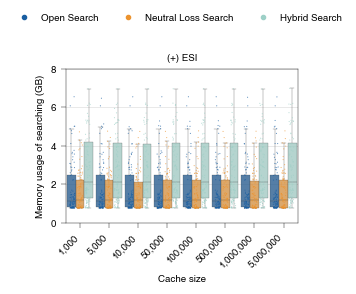

In [39]:
charge=1
save_path=path_figures / f"compare_memory_usage_search_different_cache_list_threshold_charge_{charge}.svg"
ylim=(0, 8)
plot_time_search_different_cache_list(
    df_data=df_data,
    charge=charge,
    hue_order=hue_order,
    ylim=ylim,
    color_palette=color_palette,
    save_path=save_path
)

/tmp/ipykernel_7511/658167856.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(formatted_labels, rotation=45, ha='right', fontsize=matplotlib_font_size)


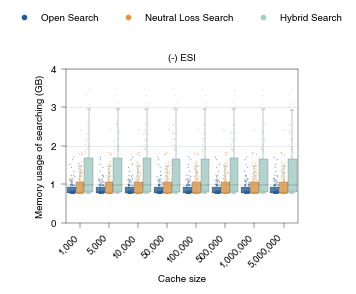

In [40]:
charge=-1
save_path=path_figures / f"compare_memory_usage_search_different_cache_list_threshold_charge_{charge}.svg"
ylim=(0, 4)
plot_time_search_different_cache_list(
    df_data=df_data,
    charge=charge,
    hue_order=hue_order,
    ylim=ylim,
    color_palette=color_palette,
    save_path=save_path
)